In [143]:
# Enable autoreload so helper edits refresh automatically.
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
warnings.filterwarnings("ignore")

from data_utils import (
    increase_resolution,
    plot_matrix,
    process_pems,
    summarize_sparsity,
    get_ramps_per_segment,
    get_lanes_per_segment,
    run_asmx
)

plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "axes.titlesize": 13,
    "figure.facecolor": "white",
})

# Edit this section for a new corridor / experiment.
CONFIG = {
    "corridor": {
        "freeway_id": 5,
        "direction": "S",
        "start_abs_pm": 120,
        "end_abs_pm": 70,
        "min_hour": 0,
        "max_hour": 24,
    },
    "grid": {
        "space_step_km": 0.4,
        "time_step_seconds": 30,
    },
    "asmx": {
        "space_factor": 1,
        "time_factor": 3,
        "c_cong": 12.26,
        "c_free": -50.40,
        "v_thr": 49.57,
        "v_delta": 10.11,
        "vmin": 0,
        "vmax": 80,
        "delta_multipliers": [0.25, 0.5, 1.0, 1.5, 2.0, 3.0],
        "tau_multipliers": [0.5, 1.0, 2.0, 3.0, 5.0, 8.0],
        "apply_flow_asmx": True,
    }
}


# Derived file paths.
MILES_TO_KM = 1.60934
ramps_path = "data/pems/I5S_ramps.csv"
lanes_path = "data/pems/I5S_lanes.csv"
station_data_path = "data/pems/district12_stations.txt"
detector_data_path = "data/pems/30_sec/d12_text_station_raw_2026_04_13.txt"

fwy_station_identifier = CONFIG["corridor"]["freeway_id"]
fwy_direction = CONFIG["corridor"]["direction"]
START_ABS_PM = CONFIG["corridor"]["start_abs_pm"]
END_ABS_PM = CONFIG["corridor"]["end_abs_pm"]
MIN_HOUR = CONFIG["corridor"]["min_hour"]
MAX_HOUR = CONFIG["corridor"]["max_hour"]

SPACE_STEP_KM = CONFIG["grid"]["space_step_km"]
SPACE_STEP_MI = SPACE_STEP_KM / MILES_TO_KM
TIME_INCREMENT_SECONDS = pd.Timedelta(seconds=CONFIG["grid"]["time_step_seconds"])

SPACE_FACTOR = CONFIG["asmx"]["space_factor"]
TIME_FACTOR = CONFIG["asmx"]["time_factor"]
C_CONG = CONFIG["asmx"]["c_cong"]
C_FREE = CONFIG["asmx"]["c_free"]
V_THR = CONFIG["asmx"]["v_thr"]
V_DELTA = CONFIG["asmx"]["v_delta"]
VMIN = CONFIG["asmx"]["vmin"]
VMAX = CONFIG["asmx"]["vmax"]
APPLY_FLOW_ASMX = CONFIG["asmx"]["apply_flow_asmx"]
delta_multipliers = CONFIG["asmx"]["delta_multipliers"]
tau_multipliers = CONFIG["asmx"]["tau_multipliers"]

print("Active corridor configuration:")
print(f"  Freeway {fwy_station_identifier} {fwy_direction}")
print(f"  PM window: {START_ABS_PM} -> {END_ABS_PM}")
print(f"  Hour window: {MIN_HOUR}:00 to {MAX_HOUR}:00")
print(f"  Grid: {SPACE_STEP_KM} km x {TIME_INCREMENT_SECONDS}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Active corridor configuration:
  Freeway 5 S
  PM window: 120 -> 70
  Hour window: 0:00 to 24:00
  Grid: 0.4 km x 0 days 00:00:30


# 1. Data Preprocessing
### 1.1 Load and Process Detector Stations, Ramp Locations, and Lane Configurations

In [144]:
# Station preprocessing:
# 1. filter the requested corridor,
# 2. infer direction of travel,
# 3. build per-bin ramp and lane mappings used downstream.

# Load station metadata
stations = pd.read_csv(station_data_path, sep="\t")
rename_map = {col: col.lower().replace(" ", "_") for col in stations.columns}
stations.rename(columns=rename_map, inplace=True)
stations.rename(columns={"id": "station_id"}, inplace=True)

# Infer the direction of the postmile progression
postmile_dxn = 1 if END_ABS_PM > START_ABS_PM else -1

# Filter to correct fwy and direction mainline/HOV stations within the desired postmile window.
stations = stations[(stations["fwy"] == fwy_station_identifier) & (stations["dir"] == fwy_direction)]
# stations = stations[stations["type"].isin(["ML", "HV"])]
stations = stations[stations['type'].isin(["ML", "HV", "OR", "FR", "FF", "CD"])]
min_pm = min(START_ABS_PM, END_ABS_PM)
max_pm = max(START_ABS_PM, END_ABS_PM)
stations = stations[(stations["abs_pm"] > min_pm) & (stations["abs_pm"] < max_pm)]

# Quick sanity check on mainline detector spacing.
print("Summary of station lengths:\n", stations["length"].describe())

# Update the start and end postmiles to the precise postmile locations of the first and last stations
if postmile_dxn == 1:
    start_pm = stations["abs_pm"].min()
    end_pm = stations["abs_pm"].max()
else:
    start_pm = stations["abs_pm"].max()
    end_pm = stations["abs_pm"].min()

# Create a ramp/lane mapping
on_ramp, off_ramp, edges = get_ramps_per_segment(ramps_path, start_pm, end_pm, SPACE_STEP_MI)
lanes_per_bin = get_lanes_per_segment(lanes_path, start_pm, end_pm, SPACE_STEP_MI, debug=True)

np.save("data/pems/on_ramp_map.npy", on_ramp)
np.save("data/pems/off_ramp_map.npy", off_ramp)
np.save("data/pems/lane_map.npy", lanes_per_bin)

# Sanity Checks
print('')
print("Number of Detected Space Bins:", len(on_ramp))
print("Range of Lanes per Bin:", lanes_per_bin.min(), "-", lanes_per_bin.max())
print('Verify Space Bin Edges:', edges)
print('')
print('Ramp Mapping:')
print('  On-Ramp:', on_ramp)
print('  Off-Ramp:', off_ramp)
print('Percent of Segments with a ramp:', np.sum((on_ramp + off_ramp) > 0) / len(on_ramp))

# save the space bin edges to a numpy file
np.save("data/pems/space_bin_edges.npy", edges)

Summary of station lengths:
 count    220.000000
mean       0.400327
std        0.226783
min        0.079000
25%        0.277250
50%        0.397000
75%        0.475000
max        2.665000
Name: length, dtype: float64
Ramp bin 0 [116.13945090534008, 116.388): 1 on-ramps, 0 off-ramps
Ramp bin 1 [115.89090181068016, 116.13945090534008): 0 on-ramps, 1 off-ramps
Ramp bin 2 [115.64235271602024, 115.89090181068016): 0 on-ramps, 0 off-ramps
Ramp bin 3 [115.39380362136032, 115.64235271602024): 0 on-ramps, 0 off-ramps
Ramp bin 4 [115.1452545267004, 115.39380362136032): 1 on-ramps, 0 off-ramps
Ramp bin 5 [114.89670543204046, 115.1452545267004): 0 on-ramps, 1 off-ramps
Ramp bin 6 [114.64815633738054, 114.89670543204046): 0 on-ramps, 1 off-ramps
Ramp bin 7 [114.39960724272062, 114.64815633738054): 0 on-ramps, 1 off-ramps
Ramp bin 8 [114.1510581480607, 114.39960724272062): 0 on-ramps, 0 off-ramps
Ramp bin 9 [113.90250905340078, 114.1510581480607): 1 on-ramps, 0 off-ramps
Ramp bin 10 [113.6539599587

### 1.2 Load and Clean Detector Demand Data


In [145]:
# Load mainline detector data (comma-separated text) and inspect the header.
demand = pd.read_csv(detector_data_path, sep=",")
demand.columns = (
    ["timestamp", "id"]
    + [
        f"lane {lane} {metric}"
        for lane in range(1, 9)
        for metric in ("flow", "occupancy", "speed")
    ]
)
rename_map = {col: col.lower().replace(" ", "_") for col in demand.columns}
demand.rename(columns=rename_map, inplace=True)
demand.rename(columns={"id": "station_id"}, inplace=True)

# Filter by hour window.
demand['timestamp'] = pd.to_datetime(demand['timestamp'])
demand = demand[
    (demand["timestamp"].dt.hour >= MIN_HOUR)
    & (demand["timestamp"].dt.hour < MAX_HOUR)
].copy()
# Round timestamps to 30-second bins.
demand["timestamp"] = demand["timestamp"].dt.floor("30S")

# For all columns containing the string 'lane', convert 0 values to nan
lane_cols = [col for col in demand.columns if "lane" in col.lower()]
demand[lane_cols] = demand[lane_cols].replace(0, np.nan)

### 1.3 Split Mainline and HOV Stations


In [146]:
print("Number of ML stations within range:", stations[stations["type"] == "ML"].shape[0])
print("Number of HOV stations within range:", stations[stations["type"] == "HV"].shape[0])
print("Number of On-Ramp stations within range:", stations[stations["type"] == "OR"].shape[0])
print("Number of Off-Ramp stations within range:", stations[stations["type"] == "FR"].shape[0])
print("Number of CD stations within range:", stations[stations["type"] == "CD"].shape[0])
print("Number of FF stations within range:", stations[stations["type"] == "FF"].shape[0])

# Join station postmile to df
demand = demand.merge(stations[["station_id", "abs_pm"]], on="station_id", how="left")

# Split mainline vs. HOV station info.
hov_stations = stations.loc[stations["type"] == "HV", ["station_id", "abs_pm", "length", "latitude", "longitude"]]
ml_stations = stations.loc[stations["type"] == "ML", ["station_id", "abs_pm", "length", "latitude", "longitude"]]

# Figure out which ML and HOV sensors share a station
ml_hov_shared = ml_stations[ml_stations["abs_pm"].isin(hov_stations["abs_pm"])]
print('')
print("Shared HOV and ML stations (by abs_pm):\n", ml_hov_shared)

# Figure out how many ML stations are standalone (no HOV readers)
ml_hov_unshared = ml_stations[~ml_stations["abs_pm"].isin(hov_stations["abs_pm"])]
print('')
print("Standalone ML stations (by abs_pm):\n", ml_hov_unshared)

# Figure out how many HOV stations are standalone (no ML readers)
hov_ml_unshared = hov_stations[~hov_stations["abs_pm"].isin(ml_stations["abs_pm"])]
print('')
print("Standalone HOV stations (by abs_pm):\n", hov_ml_unshared)

Number of ML stations within range: 115
Number of HOV stations within range: 105
Number of On-Ramp stations within range: 53
Number of Off-Ramp stations within range: 54
Number of CD stations within range: 4
Number of FF stations within range: 22

Shared HOV and ML stations (by abs_pm):
       station_id  abs_pm  length   latitude   longitude
681      1204273  75.755   0.435  33.440044 -117.624646
694      1204357  78.795   0.175  33.465471 -117.667379
704      1204415  81.595   0.475  33.499521 -117.658583
707      1204428  82.895   0.300  33.517588 -117.664664
710      1204442  83.565   0.455  33.526418 -117.668912
...          ...     ...     ...        ...         ...
2395     1221795  87.518   0.250  33.581647 -117.671917
2401     1221819  88.625   0.100  33.596833 -117.675263
2403     1221827  88.783   0.380  33.598386 -117.677370
2409     1221851  88.075   0.250  33.589674 -117.671796
2422     1222000  84.744   0.200  33.541593 -117.674195

[93 rows x 5 columns]

Standalone ML s

In [ ]:
# ramps = stations[(stations['type'] != 'HV') & (stations['type'] != 'ML')]
# ramps.to_csv("ramp_detectors.csv")

### 1.4 Inspect Data Sparsity


Mainline Data ----------------------------------------------
Mainline Data sensor readings: 304,764


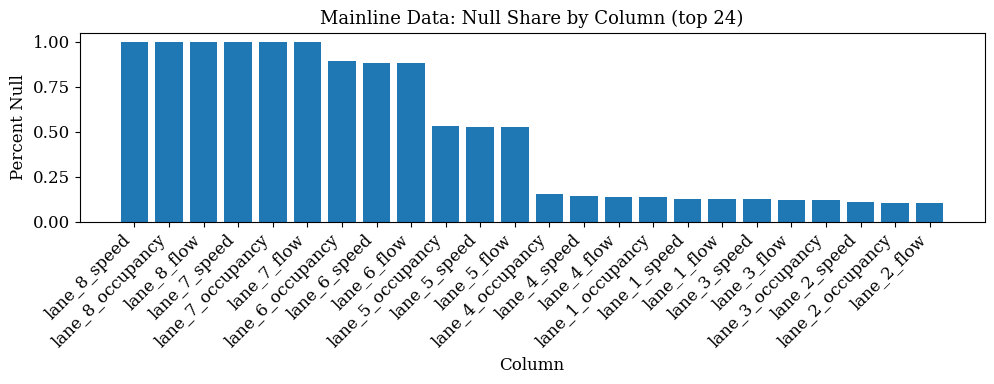

Dropping 6 fully sparse columns
Mainline Data null summary (by station_id):
Total rows: 304,764


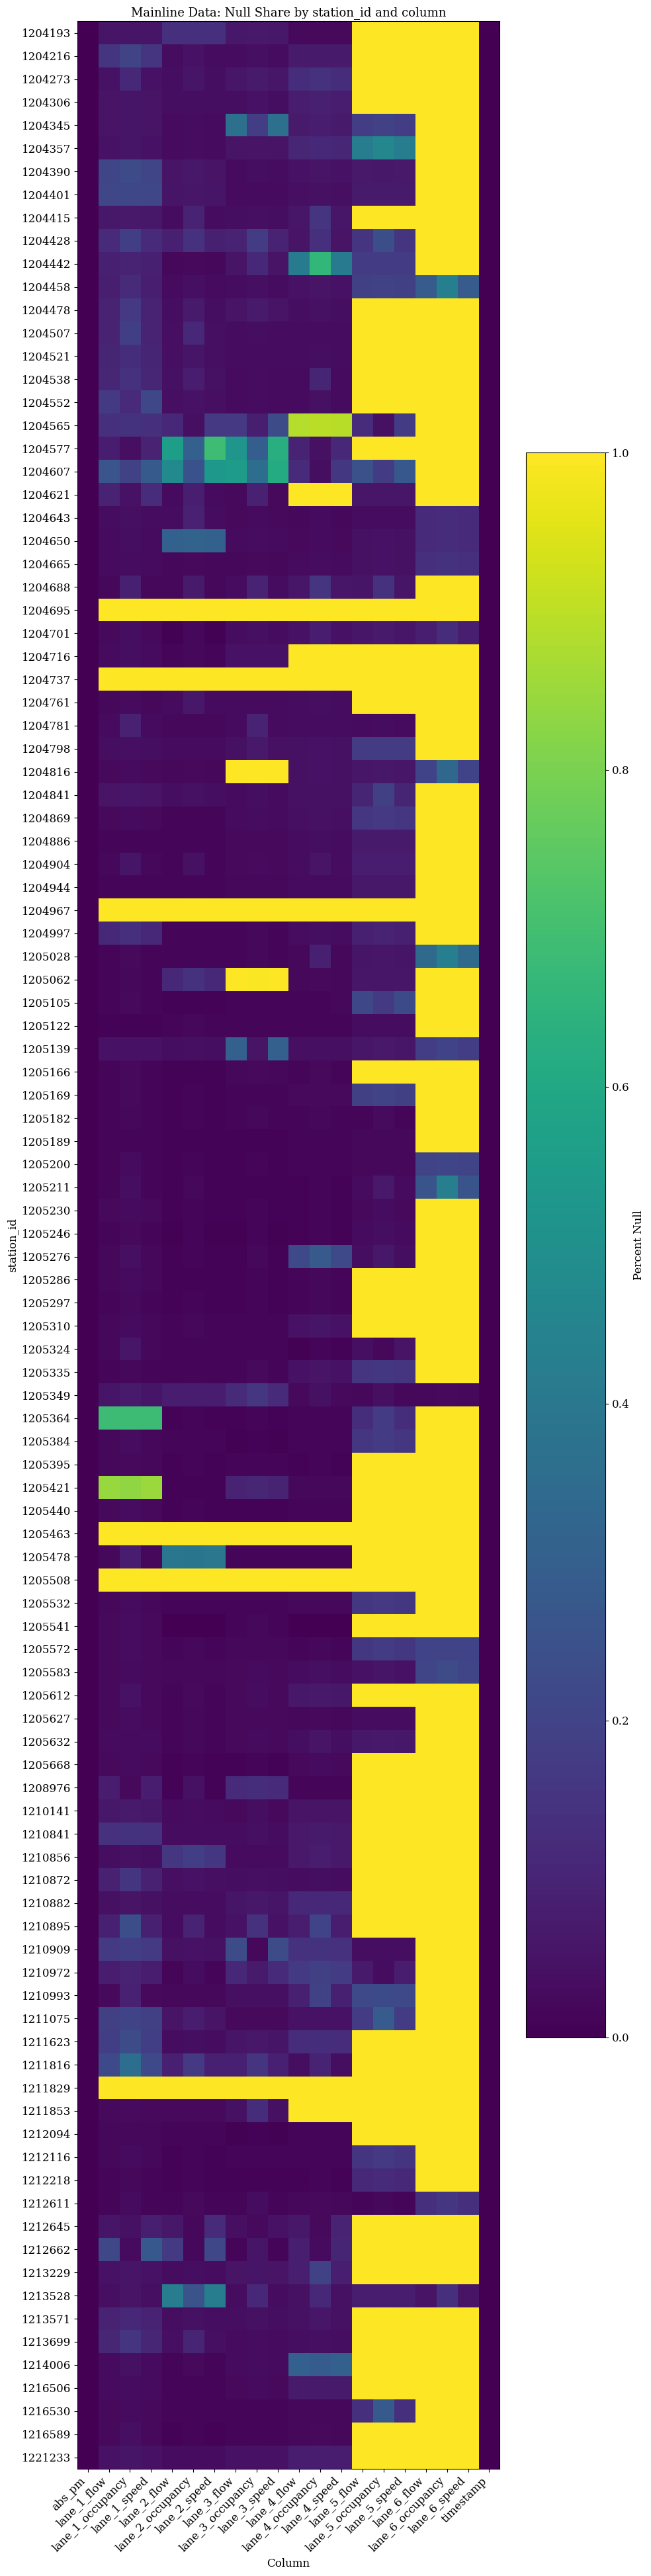

Dropping 17704 rows with no sensor data.
Summary of ML station lengths after cleaning sparse values:
 count    100.000000
mean       0.396200
std        0.145118
min        0.079000
25%        0.292500
50%        0.402500
75%        0.481250
max        0.800000
Name: length, dtype: float64

HOV Data ----------------------------------------------
HOV Data sensor readings: 281,758


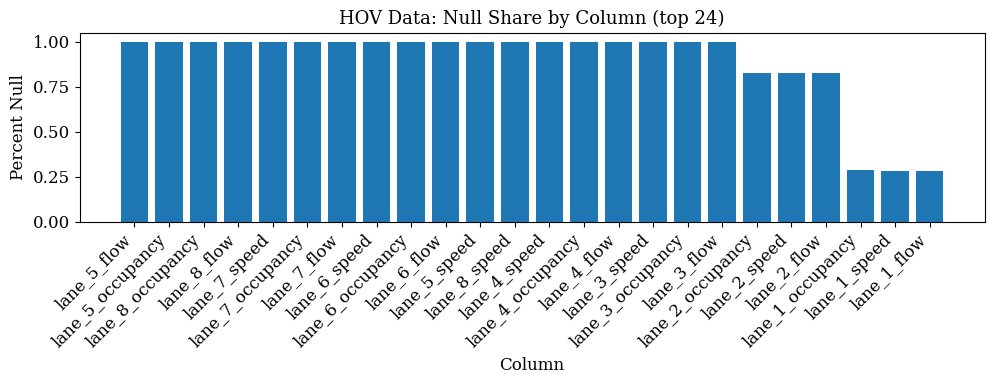

Dropping 18 fully sparse columns
HOV Data null summary (by station_id):
Total rows: 281,758


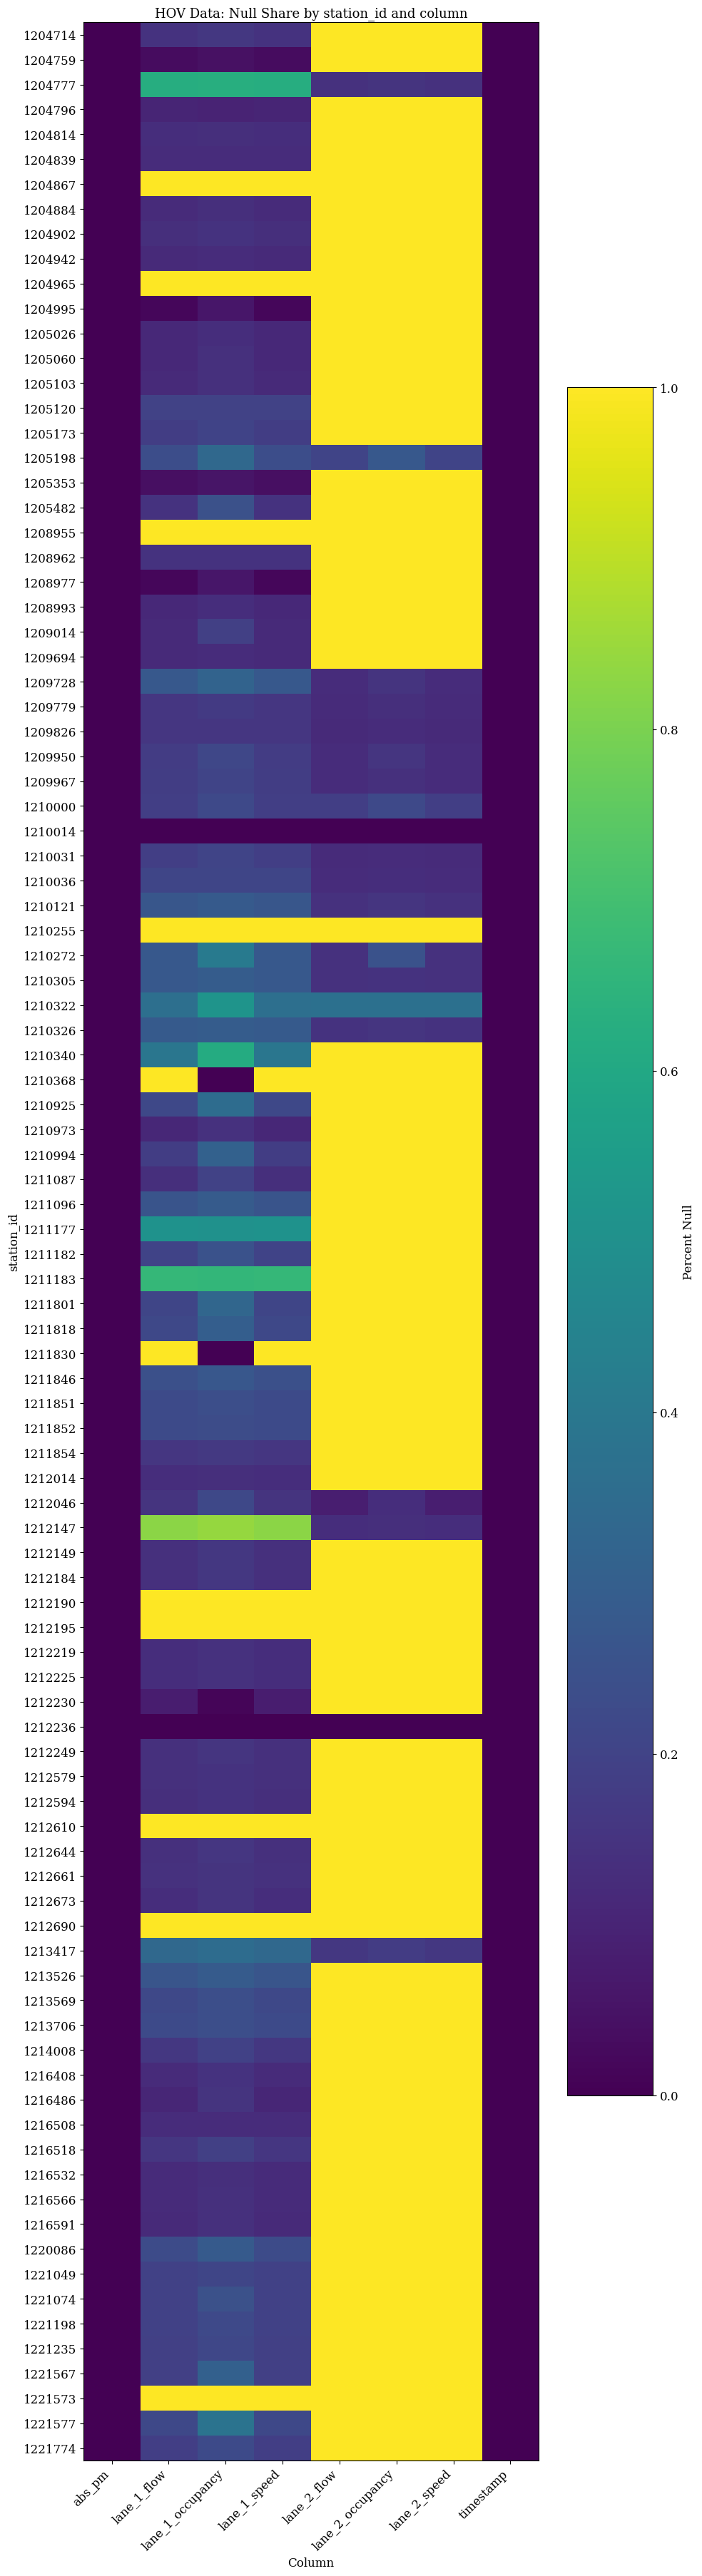

Dropping 63757 rows with no sensor data.
Summary of ML station lengths after cleaning sparse values:
 count    89.00000
mean      0.43027
std       0.31146
min       0.07900
25%       0.27800
50%       0.40000
75%       0.50000
max       2.66500
Name: length, dtype: float64

Merged HOV and ML traffic data:


,timestamp,station_id_ml,lane_1_flow_ml,lane_1_occupancy_ml,lane_1_speed_ml,lane_2_flow_ml,lane_2_occupancy_ml,lane_2_speed_ml,lane_3_flow,lane_3_occupancy,...,lane_6_occupancy,lane_6_speed,abs_pm,station_id_hov,lane_1_flow_hov,lane_1_occupancy_hov,lane_1_speed_hov,lane_2_flow_hov,lane_2_occupancy_hov,lane_2_speed_hov
0,2026-04-13,1204193.0,3.0,0.03,51.0,2.0,0.04,29.0,4.0,0.03,...,NaN,NaN,72.835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-13,1210841.0,2.0,0.01,71.0,2.0,0.01,71.0,2.0,0.01,...,NaN,NaN,73.095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-04-13,1204216.0,1.0,0.01,85.0,2.0,0.01,85.0,3.0,0.02,...,NaN,NaN,73.455,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-04-13,1210856.0,2.0,0.01,93.0,1.0,0.01,89.0,4.0,0.02,...,NaN,NaN,73.685,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-04-13,1210872.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,74.335,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [147]:
# --- Mainline detectors -----------------------------------------------------
print('Mainline Data ----------------------------------------------')
ml_ids = ml_stations["station_id"].unique()
ml_data = demand[demand["station_id"].isin(ml_ids)].copy()

ml_column_sparsity = summarize_sparsity(ml_data, label='Mainline Data', mode='column_nulls')
# ml_detector_sparsity = summarize_sparsity(ml_data, label='Mainline Data', mode='lane_all_null_by_id')

# get column names that have 100% sparsity
fully_sparse_cols = ml_column_sparsity[ml_column_sparsity['percent_null'] == 1.0]['column'].tolist()
print("Dropping", len(fully_sparse_cols), "fully sparse columns")

# Remove fully sparse columns
ml_data.drop(columns=fully_sparse_cols, inplace=True)

ml_station_sparsity = summarize_sparsity(ml_data, label='Mainline Data', mode='by_station', group_col='station_id')

# Drop rows with no lane data (keeping timestamp/station_id)
num_dropped_rows = ml_data[ml_data.columns.difference(["timestamp", "station_id", "abs_pm"])].isna().all(axis=1).sum()
print("Dropping", num_dropped_rows, "rows with no sensor data.")
ml_data.dropna(how="all", subset=ml_data.columns.difference(["timestamp", "station_id", "abs_pm"]), inplace=True)

# Summarize lengths between ML detectors AFTER dropping sparse detectors
ml_ids = ml_data["station_id"].unique()
ml_stations = ml_stations[ml_stations["station_id"].isin(ml_ids)].copy()
print("Summary of ML station lengths after cleaning sparse values:\n", ml_stations["length"].describe())

# --- HOV / Managed-lane detectors ------------------------------------------
print('')
print('HOV Data ----------------------------------------------')
hov_ids = hov_stations["station_id"].unique()
hov_data = demand[demand["station_id"].isin(hov_ids)].copy()

hov_column_sparsity = summarize_sparsity(hov_data, label='HOV Data', mode='column_nulls')
# hov_detector_sparsity = summarize_sparsity(hov_data, label='HOV Data', mode='lane_all_null_by_id')

# Get column names that have 100% sparsity
fully_sparse_cols = hov_column_sparsity[hov_column_sparsity['percent_null'] == 1.0]['column'].tolist()
print("Dropping", len(fully_sparse_cols), "fully sparse columns")

# Drop all columns with full sparsity
hov_data.drop(columns=fully_sparse_cols, inplace=True)

hov_station_sparsity = summarize_sparsity(hov_data, label='HOV Data', mode='by_station', group_col='station_id')

# Drop rows with no lane data (keeping timestamp/station_id)
num_dropped_rows = hov_data[hov_data.columns.difference(["timestamp", "station_id", "abs_pm"])].isna().all(axis=1).sum()
print("Dropping", num_dropped_rows, "rows with no sensor data.")
hov_data.dropna(how="all", subset=hov_data.columns.difference(["timestamp", "station_id", "abs_pm"]), inplace=True)

# Summarize lengths between HOV detectors AFTER dropping sparse detectors
hov_ids = hov_data["station_id"].unique()
hov_stations = hov_stations[hov_stations["station_id"].isin(hov_ids)].copy()
print("Summary of ML station lengths after cleaning sparse values:\n", hov_stations["length"].describe())

# Merge mainline + HOV data on the shared postmile/timestamp grid.
all_data = ml_data.merge(hov_data, on=["timestamp", "abs_pm"], how="outer", suffixes=("_ml", "_hov"))
# all_data = ml_data
print()
print('Merged HOV and ML traffic data:')
all_data.head()

### 1.5 Build Flow Observations


In [148]:
# Keep only flow-related columns (drop occupancy/speed).
flow_cols = all_data.columns[~all_data.columns.str.contains("occupancy|speed", case=False)]
flow = all_data.loc[:, flow_cols].copy()

# Identify all flow columns once for reuse.
flow_measure_cols = [col for col in flow.columns if "flow" in col.lower()]

# Aggregate total flow (vehicles / 30s) across all available lanes.
flow["total_flow"] = flow[flow_measure_cols].sum(axis=1)

# Count how many lanes report valid flow on each row.
flow["num_lanes"] = flow[flow_measure_cols].notna().sum(axis=1)

# Normalize per lane per hour (30-second interval -> multiply by 120).
flow["flow_per_lane_per_hour"] = flow["total_flow"] / flow["num_lanes"] * 120

flow.head()

,timestamp,station_id_ml,lane_1_flow_ml,lane_2_flow_ml,lane_3_flow,lane_4_flow,lane_5_flow,lane_6_flow,abs_pm,station_id_hov,lane_1_flow_hov,lane_2_flow_hov,total_flow,num_lanes,flow_per_lane_per_hour
0,2026-04-13,1204193.0,3.0,2.0,4.0,3.0,NaN,NaN,72.835,NaN,NaN,NaN,12.0,4,360.0
1,2026-04-13,1210841.0,2.0,2.0,2.0,3.0,NaN,NaN,73.095,NaN,NaN,NaN,9.0,4,270.0
2,2026-04-13,1204216.0,1.0,2.0,3.0,2.0,NaN,NaN,73.455,NaN,NaN,NaN,8.0,4,240.0
3,2026-04-13,1210856.0,2.0,1.0,4.0,2.0,NaN,NaN,73.685,NaN,NaN,NaN,9.0,4,270.0
4,2026-04-13,1210872.0,NaN,NaN,NaN,2.0,NaN,NaN,74.335,NaN,NaN,NaN,2.0,1,240.0


### 1.6 Build Speed Observations


In [149]:
# Keep only speed-related columns (drop any flow or occupancy metrics).
speed_cols = all_data.columns[~all_data.columns.str.contains("occupancy|flow", case=False)]
speed = all_data.loc[:, speed_cols].copy()

# Identify all speed columns once for reuse.
speed_measure_cols = [col for col in speed.columns if "speed" in col.lower()]

# Compute the per-row average speed across available lanes.
speed["avg_speed"] = speed[speed_measure_cols].mean(axis=1)

speed.head()

,timestamp,station_id_ml,lane_1_speed_ml,lane_2_speed_ml,lane_3_speed,lane_4_speed,lane_5_speed,lane_6_speed,abs_pm,station_id_hov,lane_1_speed_hov,lane_2_speed_hov,avg_speed
0,2026-04-13,1204193.0,51.0,29.0,82.0,82.0,NaN,NaN,72.835,NaN,NaN,NaN,61.00
1,2026-04-13,1210841.0,71.0,71.0,63.0,80.0,NaN,NaN,73.095,NaN,NaN,NaN,71.25
2,2026-04-13,1204216.0,85.0,85.0,85.0,31.0,NaN,NaN,73.455,NaN,NaN,NaN,71.50
3,2026-04-13,1210856.0,93.0,89.0,99.0,37.0,NaN,NaN,73.685,NaN,NaN,NaN,79.50
4,2026-04-13,1210872.0,NaN,NaN,NaN,87.0,NaN,NaN,74.335,NaN,NaN,NaN,87.00


### 1.7 Perform Gridding into Time-Space Matrices

In [150]:
# Grid detector observations into matrices with rows=space and cols=time.
# The output paths are defined once in CONFIG.

# --- PeMS gridding parameters -------------------------------------------------
time_increment_seconds = TIME_INCREMENT_SECONDS
time_col = "timestamp"
postmile_col = "abs_pm"

# --- Build speed/flow matrices -----------------------------------------------
speed_matrix, speed_df = process_pems(
    speed,
    time_col=time_col,
    postmile_col=postmile_col,
    value_col="avg_speed",
    start_pm=start_pm,
    end_pm=end_pm,
    time_interval=time_increment_seconds,
    space_interval=SPACE_STEP_MI
)

flow_matrix, flow_df = process_pems(
    flow,
    time_col=time_col,
    postmile_col=postmile_col,
    value_col="flow_per_lane_per_hour",
    start_pm=start_pm,
    end_pm=end_pm,
    time_interval=time_increment_seconds,
    space_interval=SPACE_STEP_MI
)

# Save flow and speed dfs to csv if desired
# speed_df.to_csv(array_dir / "v_hat_raw", index=False)
# flow_df.to_csv(array_dir / "q_hat_raw", index=False)

### 1.8 Visualize Raw Gridded Matrices


inferred time increment: 0 days 00:00:30
inferred space increment: -0.4 km
num time bins: 2879
num space bins: 176
num space edges: 176


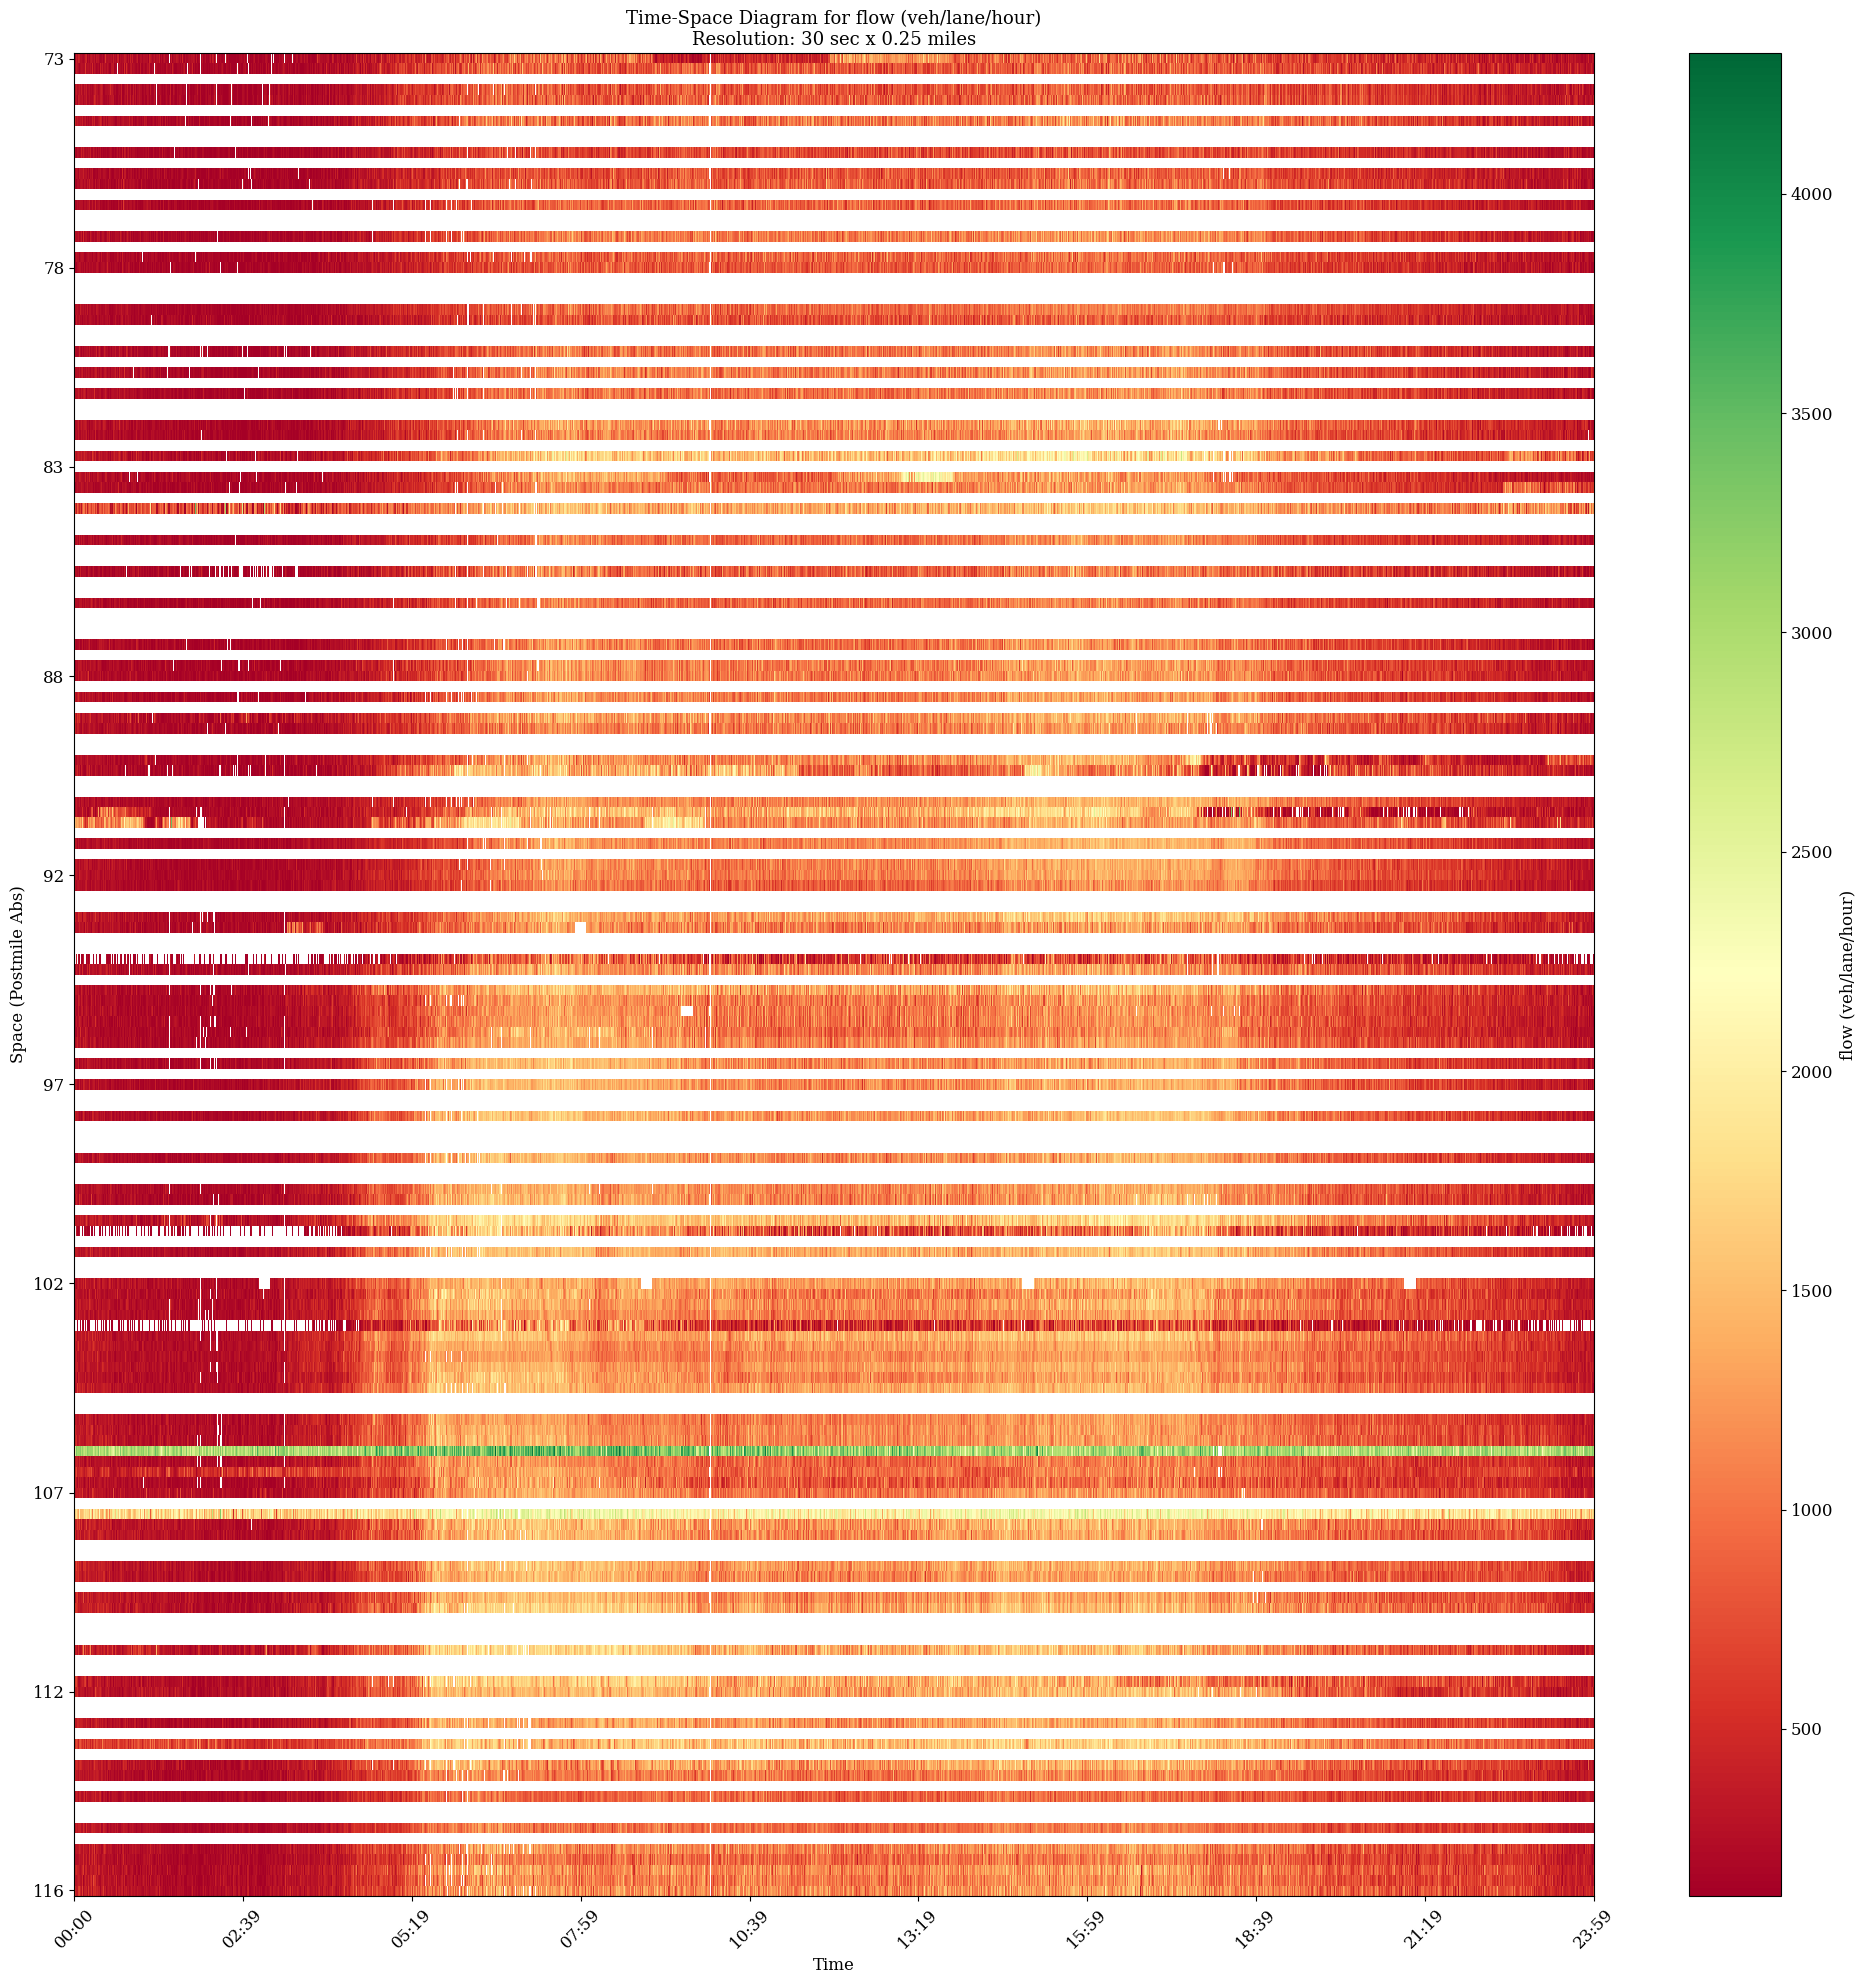

inferred time increment: 0 days 00:00:30
inferred space increment: -0.4 km
num time bins: 2879
num space bins: 176
num space edges: 176


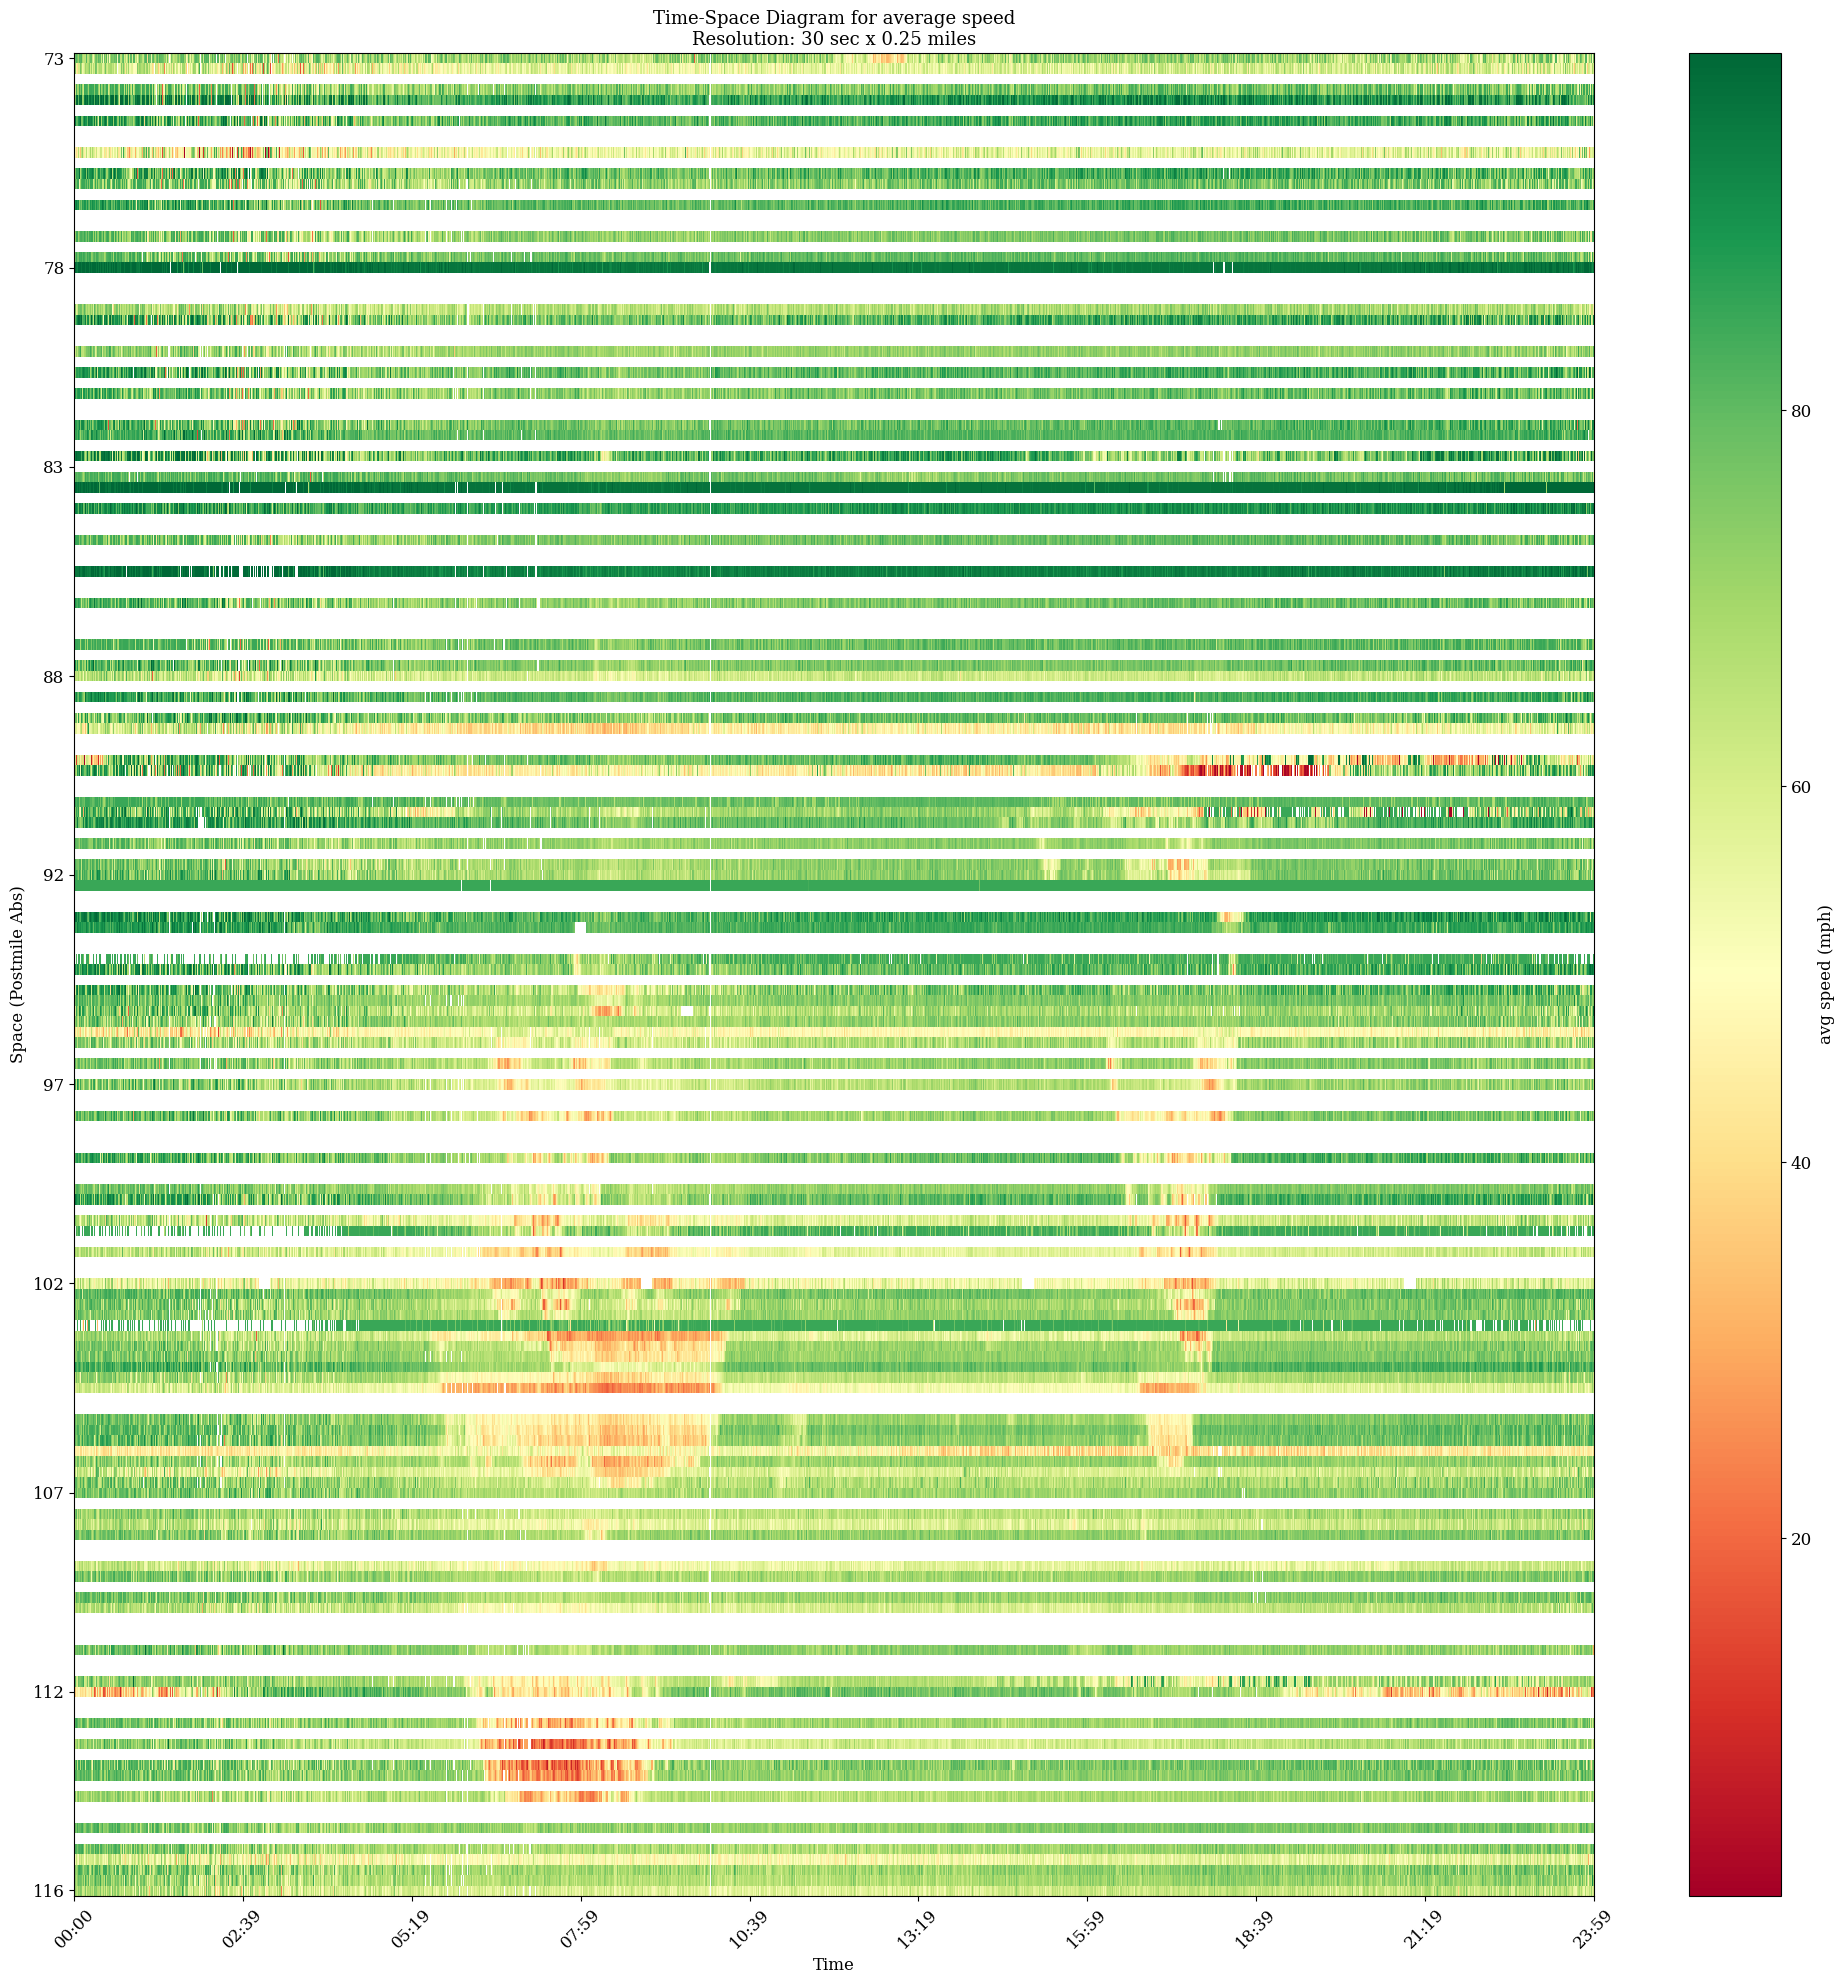

In [151]:
t_min = flow[time_col].min()
t_max = flow[time_col].max()

plot_matrix(flow_matrix, "flow (veh/lane/hour)", t_min=t_min, t_max=t_max, start_pm=start_pm, end_pm=end_pm)
plot_matrix(speed_matrix, "average speed", "avg speed (mph)", t_min=t_min, t_max=t_max, start_pm=start_pm, end_pm=end_pm)

In [152]:
np.save("data/pems/30_sec/i5_s_speed_matrix_04_13", speed_matrix)
np.save("data/pems/30_sec/i5_s_flow_matrix_04_13", flow_matrix)